<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Introduction to NumPy](02.00-Introduction-to-NumPy.ipynb) | [Contents](Index.ipynb) | [The Basics of NumPy Arrays](02.02-The-Basics-Of-NumPy-Arrays.ipynb) >

# 2.1 Understanding Data Types in Python / 理解Python中的数据类型

Effective data-driven science and computation requires understanding how data is stored and manipulated.
This section outlines and contrasts how arrays of data are handled in the Python language itself, and how NumPy improves on this.
Understanding this difference is fundamental to understanding much of the material throughout the rest of the book.

🐍 Python其中一个易用之处就在于动态输入, 这意味着可以将任何类型的数据指定给任何变量

Users of Python are often drawn-in by its ease of use, one piece of which is dynamic typing.
While a statically-typed language like C or Java requires each variable to be explicitly declared, a dynamically-typed language like Python skips this specification. For example, in C you might specify a particular operation as follows:

```C
/* C code */
int result = 0;
for(int i=0; i<100; i++){
    result += i;
}
```

While in Python the equivalent operation could be written this way:

```python
# Python code
result = 0
for i in range(100):
    result += i
```

Notice the main difference: in C, the data types of each variable are explicitly declared, while in Python the types are dynamically inferred. This means, for example, that we can assign any kind of data to any variable:

```python
# Python code
x = 4
x = "four"
```

Here we've switched the contents of ``x`` from an integer to a string. The same thing in C would lead (depending on compiler settings) to a compilation error or other unintented consequences:

```C
/* C code */
int x = 4;
x = "four";  // FAILS
```

This sort of flexibility is one piece that makes Python and other dynamically-typed languages convenient and easy to use.
Understanding *how* this works is an important piece of learning to analyze data efficiently and effectively with Python.
But what this type-flexibility also points to is the fact that Python variables are more than just their value; they also contain extra information about the type of the value. We'll explore this more in the sections that follow.

🐍 Python 变量不仅是它们的值，还包括了关于值的类型的一些额外信息

## 2.1.1 A Python Integer Is More Than Just an Integer / Python整型不仅仅是一个整型

The standard Python implementation is written in C.
This means that every Python object is simply a cleverly-disguised C structure, which contains not only its value, but other information as well. For example, when we define an integer in Python, such as ``x = 10000``, ``x`` is not just a "raw" integer. It's actually a pointer to a compound C structure, which contains several values.
Looking through the Python 3.4 source code, we find that the integer (long) type definition effectively looks like this (once the C macros are expanded):

🐍 标准的Python 实现是用 C 语言编写的。这意味着每一个 Python对象都是一个聪明的伪C语言结构体，该结构体不仅包含其值，还有其他信息。

```C
struct _longobject {
    long ob_refcnt;
    PyTypeObject *ob_type;
    size_t ob_size;
    long ob_digit[1];
};
```

A single integer in Python 3.4 actually contains four pieces:

- ``ob_refcnt``, a reference count that helps Python silently handle memory allocation and deallocation
- ``ob_type``, which encodes the type of the variable
- ``ob_size``, which specifies the size of the following data members
- ``ob_digit``, which contains the actual integer value that we expect the Python variable to represent.

🐍 Python 3.4 中的一个整型实际上包括4 个部分。

• ob_refcnt 是一个引用计数，它帮助Python 默默地处理内存的分配和回收。

• ob_type 将变量的类型编码。

• ob_size 指定接下来的数据成员的大小。

• ob_digit 包含我们希望Python 变量表示的实际整型值。

This means that there is some overhead in storing an integer in Python as compared to an integer in a compiled language like C, as illustrated in the following figure:

![Integer Memory Layout](b02_fig/§2_1_cint_vs_pyint.png)

Here ``PyObject_HEAD`` is the part of the structure containing the reference count, type code, and other pieces mentioned before.

Notice the difference here: a C integer is essentially a label for a position in memory whose bytes encode an integer value.
A Python integer is a pointer to a position in memory containing all the Python object information, including the bytes that contain the integer value.
This extra information in the Python integer structure is what allows Python to be coded so freely and dynamically.
All this additional information in Python types comes at a cost, however, which becomes especially apparent in structures that combine many of these objects.

🐍 两者的差异在于，C 语言整型本质上是对应某个内存位置的标签，里面存储的字节会编码成整型。

🐍 而Python 的整型其实是一个指针，指向包含这个 Python 对象所有信息的某个内存位置，其中包括可以转换成整型的字节。

## 2.1.2 A Python List Is More Than Just a List / Python列表不仅仅是一个列表

Let's consider now what happens when we use a Python data structure that holds many Python objects.
The standard mutable multi-element container in Python is the list.
We can create a list of integers as follows:

In [1]:
L = list(range(10))
L

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [2]:
type(L[0])

int

Or, similarly, a list of strings:

In [3]:
L2 = [str(c) for c in L]
L2

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [4]:
type(L2[0])

str

Because of Python's dynamic typing, we can even create heterogeneous lists:

In [5]:
#🐍 创建一个异构的列表

L3 = [True, "2", 3.0, 4]
[type(item) for item in L3]

[bool, str, float, int]

In [6]:
type(L3)

list

But this flexibility comes at a cost: to allow these flexible types, each item in the list must contain its own type info, reference count, and other information–that is, each item is a complete Python object.
In the special case that all variables are of the same type, much of this information is redundant: it can be much more efficient to store data in a fixed-type array.
The difference between a dynamic-type list and a fixed-type (NumPy-style) array is illustrated in the following figure:

![Array Memory Layout](figures/§2_1_array_vs_list.png)

At the implementation level, the array essentially contains a single pointer to one contiguous block of data.
The Python list, on the other hand, contains a pointer to a block of pointers, each of which in turn points to a full Python object like the Python integer we saw earlier.
Again, the advantage of the list is flexibility: because each list element is a full structure containing both data and type information, the list can be filled with data of any desired type.
Fixed-type NumPy-style arrays lack this flexibility, but are much more efficient for storing and manipulating data.

## 2.1.3 Fixed-Type Arrays in Python / Python中的固定类型数组

Python offers several different options for storing data in efficient, fixed-type data buffers.
The built-in ``array`` module (available since Python 3.3) can be used to create dense arrays of a uniform type:

In [7]:
#🐍 Python 内置的数组（array）模块 可以用于创建统一类型的密集数组：

import array
L = list(range(10))
A = array.array('i', L)
A

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Here ``'i'`` is a type code indicating the contents are integers.

Much more useful, however, is the ``ndarray`` object of the NumPy package.
While Python's ``array`` object provides efficient storage of array-based data, NumPy adds to this efficient *operations* on that data.
We will explore these operations in later sections; here we'll demonstrate several ways of creating a NumPy array.

We'll start with the standard NumPy import, under the alias ``np``:

In [8]:
import numpy as np
import pandas as pd

## 2.1.4 Creating Arrays from Python Lists / 从Python列表创建数组

First, we can use ``np.array`` to create arrays from Python lists:

In [9]:
# integer array:
np.array([1, 4, 2, 5, 3])

array([1, 4, 2, 5, 3])

Remember that unlike Python lists, NumPy is constrained to arrays that all contain the same type.
If types do not match, NumPy will upcast if possible (here, integers are up-cast to floating point):

#🐍 请记住，不同于Python 列表，NumPy 要求数组必须包含同一类型的数据。如果类型不匹配，NumPy 将会向上转换（如果可行）

In [10]:
np.array([3.14, 'pd', 2, 3])

array(['3.14', 'pd', '2', '3'], dtype='<U32')

If we want to explicitly set the data type of the resulting array, we can use the ``dtype`` keyword:

In [11]:
#🐍 明确设置数组的数据类型，用 dtype 关键字

np.array([1, 2, 3, 4], dtype='float32')

array([1., 2., 3., 4.], dtype=float32)

Finally, unlike Python lists, NumPy arrays can explicitly be multi-dimensional; here's one way of initializing a multidimensional array using a list of lists:

#🐍 不同于Python 列表，NumPy 数组可以被指定为多维的

In [15]:
# 🐍 nested lists result in multi-dimensional arrays
# 🐍 使用列表推导式创建一个包含嵌套列表的列表 --> 参考M3

a = np.array([range(i, i + 3) for i in [2, 4, 6]])
a

array([[2, 3, 4],
       [4, 5, 6],
       [6, 7, 8]])

In [19]:
a.ndim
a.shape
a.size

9

The inner lists are treated as rows of the resulting two-dimensional array.

## 2.1.4 Creating Arrays from Scratch / 从Python列表创建数组

Especially for larger arrays, it is more efficient to create arrays from scratch using routines built into NumPy.
Here are several examples:

In [20]:
# Create a length-10 integer array filled with zeros
np.zeros(10, dtype=int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [21]:
# Create a 3x5 floating-point array filled with ones
np.ones((3, 5), dtype=float)

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [22]:
# Create a 3x5 array filled with 3.14
np.full((3, 5), 3.14)

array([[3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14]])

In [23]:
# Create an array filled with a linear sequence
# Starting at 0, ending at 20, stepping by 2
# (this is similar to the built-in range() function)
np.arange(0, 20, 2)

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [24]:
#🐍 Python 内置 range() 函数

a = list(range(0, 20, 2))
a

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [25]:
# Create an array of five values evenly spaced between 0 and 1
#🐍 np.linspace(): 创建一个5个元素的数组，这5个数均匀地分配到0~1

np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

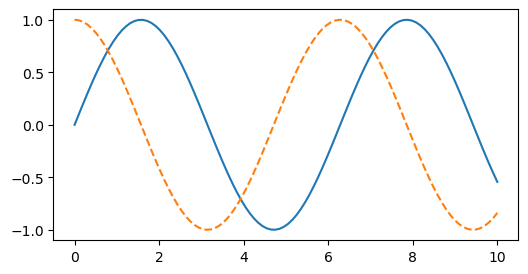

In [26]:
#🐍 示例：绘图，参考 §b04.00
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)

fig = plt.figure(figsize=(6, 3))
plt.plot(x, np.sin(x), '-')
plt.plot(x, np.cos(x), '--');

In [6]:
# Create a 3x3 array of uniformly distributed
# random values between 0 and 1
#🐍 创建一个3×3的、在0~1均匀分布的随机数组成的数组

np.random.random((3, 3))

array([[0.33723602, 0.88804015, 0.8550534 ],
       [0.98495981, 0.24188194, 0.86099298],
       [0.34273548, 0.13273358, 0.28085448]])

In [7]:
# Create a 3x3 array of normally distributed random values
# with mean 0 and standard deviation 1
#🐍 创建一个3×3的、均值为0、方差为1的

np.random.normal(0, 1, (3, 3))

array([[-0.46399332, -1.34127099,  0.315764  ],
       [ 0.38844125, -0.61877664, -0.98121101],
       [-0.94344431, -1.6330432 , -0.58432823]])

In [8]:
# Create a 3x3 array of random integers in the interval [0, 10)
#🐍 创建一个3×3的、[0, 10)区间的随机整型数组

np.random.randint(0, 10, (3, 3))

array([[5, 4, 5],
       [4, 7, 8],
       [4, 8, 3]])

In [27]:
# Create a 3x3 identity matrix
#🐍 创建一个3×3的单位矩阵

np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [28]:
# Create an uninitialized array of three integers
# The values will be whatever happens to already exist at that memory location

#🐍 创建一个由3个整型数组成的未初始化的数组
#🐍 数组的值是内存空间中的任意值

np.empty(3)

array([1., 1., 1.])

## 2.1.6 NumPy Standard Data Types / NumPy标准数据类型

NumPy arrays contain values of a single type, so it is important to have detailed knowledge of those types and their limitations.
Because NumPy is built in C, the types will be familiar to users of C, Fortran, and other related languages.

The standard NumPy data types are listed in the following table.
Note that when constructing an array, they can be specified using a string:

🐍 当构建一个数组时，你可以用一个字符串参数来指定数据类型

```python
np.zeros(10, dtype='int16')
```

Or using the associated NumPy object:

```python
np.zeros(10, dtype=np.int16)
```

| Data type	    | Description |
|---------------|-------------|
| ``bool_``     | Boolean (True or False) stored as a byte |
| ``int_``      | Default integer type (same as C ``long``; normally either ``int64`` or ``int32``)| 
| ``intc``      | Identical to C ``int`` (normally ``int32`` or ``int64``)| 
| ``intp``      | Integer used for indexing (same as C ``ssize_t``; normally either ``int32`` or ``int64``)| 
| ``int8``      | Byte (-128 to 127)| 
| ``int16``     | Integer (-32768 to 32767)|
| ``int32``     | Integer (-2147483648 to 2147483647)|
| ``int64``     | Integer (-9223372036854775808 to 9223372036854775807)| 
| ``uint8``     | Unsigned integer (0 to 255)| 
| ``uint16``    | Unsigned integer (0 to 65535)| 
| ``uint32``    | Unsigned integer (0 to 4294967295)| 
| ``uint64``    | Unsigned integer (0 to 18446744073709551615)| 
| ``float_``    | Shorthand for ``float64``.| 
| ``float16``   | Half precision float: sign bit, 5 bits exponent, 10 bits mantissa| 
| ``float32``   | Single precision float: sign bit, 8 bits exponent, 23 bits mantissa| 
| ``float64``   | Double precision float: sign bit, 11 bits exponent, 52 bits mantissa| 
| ``complex_``  | Shorthand for ``complex128``.| 
| ``complex64`` | Complex number, represented by two 32-bit floats| 
| ``complex128``| Complex number, represented by two 64-bit floats| 

![Numpy_Data_Types](figures/§2_1_numpy_data_types.png)

More advanced type specification is possible, such as specifying big or little endian numbers; for more information, refer to the [NumPy documentation](http://numpy.org/).
NumPy also supports compound data types, which will be covered in [Structured Data: NumPy's Structured Arrays](02.09-Structured-Data-NumPy.ipynb).

<!--NAVIGATION-->
< [Introduction to NumPy](02.00-Introduction-to-NumPy.ipynb) | [Contents](Index.ipynb) | [The Basics of NumPy Arrays](02.02-The-Basics-Of-NumPy-Arrays.ipynb) >